In [5]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


In [6]:
# Load dataset and convert it into real datetime format

RAW_PATH = "../../datasets/processed/cpcb_historical_clean.csv"

df = pd.read_csv(RAW_PATH)
df['datetimeLocal'] = pd.to_datetime(df['datetimeLocal'])

df.head()

,location_id,location_name,parameter,value,unit,datetimeUtc,datetimeLocal,timezone,latitude,longitude,owner_name,provider,source_file
0,10918,"Ballygunge, Kolkata - WBPCB",co,460.0,µg/m³,2022-01-01 07:30:00+00:00,2022-01-01 13:00:00+05:30,Asia/Kolkata,22.536751,88.363802,West Bengal Pollution Control Board,CPCB,Ballygunge.csv
1,10918,"Ballygunge, Kolkata - WBPCB",co,450.0,µg/m³,2022-01-01 08:30:00+00:00,2022-01-01 14:00:00+05:30,Asia/Kolkata,22.536751,88.363802,West Bengal Pollution Control Board,CPCB,Ballygunge.csv
2,10918,"Ballygunge, Kolkata - WBPCB",co,730.0,µg/m³,2022-01-01 11:30:00+00:00,2022-01-01 17:00:00+05:30,Asia/Kolkata,22.536751,88.363802,West Bengal Pollution Control Board,CPCB,Ballygunge.csv
3,10918,"Ballygunge, Kolkata - WBPCB",co,1320.0,µg/m³,2022-01-01 12:30:00+00:00,2022-01-01 18:00:00+05:30,Asia/Kolkata,22.536751,88.363802,West Bengal Pollution Control Board,CPCB,Ballygunge.csv
4,10918,"Ballygunge, Kolkata - WBPCB",co,550.0,µg/m³,2022-01-02 00:30:00+00:00,2022-01-02 06:00:00+05:30,Asia/Kolkata,22.536751,88.363802,West Bengal Pollution Control Board,CPCB,Ballygunge.csv


In [7]:
# Shape,column and dtype

print("Shape:", df.shape)
print()
df.info()

Shape: (35974, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35974 entries, 0 to 35973
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype                    
---  ------         --------------  -----                    
 0   location_id    35974 non-null  int64                    
 1   location_name  35974 non-null  object                   
 2   parameter      35974 non-null  object                   
 3   value          35974 non-null  float64                  
 4   unit           35974 non-null  object                   
 5   datetimeUtc    35974 non-null  object                   
 6   datetimeLocal  35974 non-null  datetime64[ns, UTC+05:30]
 7   timezone       35974 non-null  object                   
 8   latitude       35974 non-null  float64                  
 9   longitude      35974 non-null  float64                  
 10  owner_name     35974 non-null  object                   
 11  provider       35974 non-null  object                   
 12

In [8]:
# Prints station, pollutants and data-range

print("Stations:")
print(df['location_name'].unique())
print()
print("Pollutants:", df['parameter'].unique())
print()
print("Date range:", df['datetimeLocal'].min(), "to", df['datetimeLocal'].max())

Stations:
['Ballygunge, Kolkata - WBPCB' 'Bidhannagar, Kolkata - WBPCB'
 'Fort William, Kolkata - WBPCB' 'Jadavpur, Kolkata - WBPCB'
 'Rabindra Sarobar, Kolkata - WBPCB' 'Victoria, Kolkata - WBPCB']

Pollutants: ['co' 'no2' 'o3' 'pm10' 'pm25' 'so2']

Date range: 2022-01-01 06:00:00+05:30 to 2022-05-09 16:15:00+05:30


In [9]:
print("Rows per station:")
display(df['location_name'].value_counts())
print()
print("Rows per pollutant:")
display(df['parameter'].value_counts())

Rows per station:


location_name
Bidhannagar, Kolkata - WBPCB         6000
Jadavpur, Kolkata - WBPCB            5998
Rabindra Sarobar, Kolkata - WBPCB    5996
Ballygunge, Kolkata - WBPCB          5995
Victoria, Kolkata - WBPCB            5993
Fort William, Kolkata - WBPCB        5992
Name: count, dtype: int64


Rows per pollutant:


parameter
pm10    6000
pm25    6000
no2     5999
so2     5998
co      5994
o3      5983
Name: count, dtype: int64

In [10]:
# Selecting PM2.5 data as sample for a single station to analyze time consistency and detect missing hourly readings

sample = df[(df['location_name'] == df['location_name'].iloc[0]) & (df['parameter'] == 'pm25')]
sample = sample.sort_values('datetimeLocal')
gaps = sample['datetimeLocal'].diff().value_counts().head(10)
print(gaps)
print()
print("Most readings are roughly hourly, but there are gaps — we'll need to handle this in cleaning.")

datetimeLocal
0 days 01:00:00    817
0 days 01:15:00     66
0 days 00:45:00     63
0 days 02:00:00      9
0 days 02:15:00      3
0 days 03:00:00      3
0 days 07:00:00      3
0 days 12:00:00      2
0 days 05:00:00      2
0 days 04:00:00      2
Name: count, dtype: int64

Most readings are roughly hourly, but there are gaps — we'll need to handle this in cleaning.


In [13]:
# Missing values check
 
df.isna().sum()

location_id      0
location_name    0
parameter        0
value            0
unit             0
datetimeUtc      0
datetimeLocal    0
timezone         0
latitude         0
longitude        0
owner_name       0
provider         0
source_file      0
dtype: int64

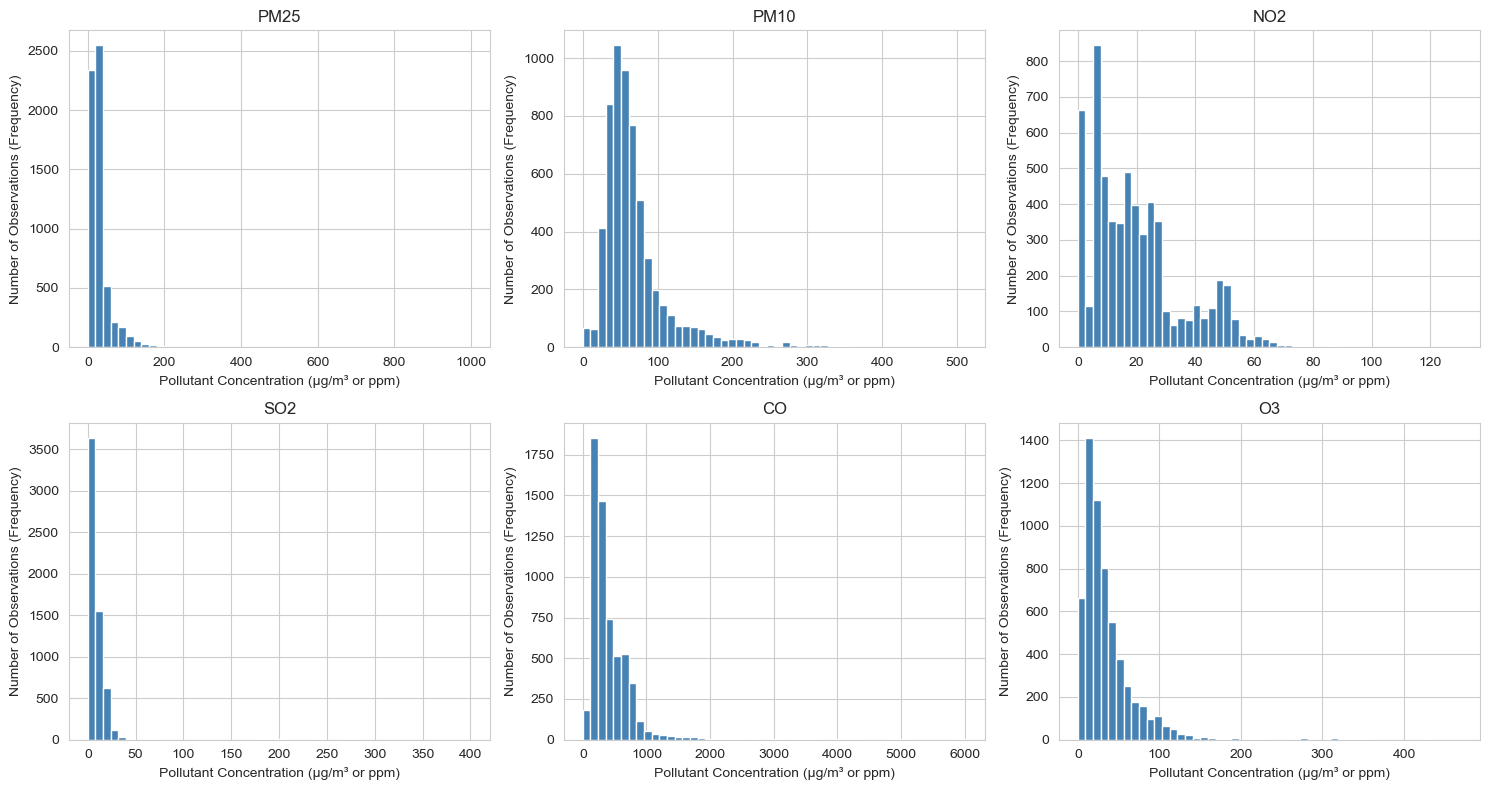

In [21]:
# Plot the distribution of each pollutant

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
for ax, p in zip(axes.flat, pollutants):
    vals = df.loc[df['parameter'] == p, 'value']
    ax.hist(vals, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(p.upper())
    ax.set_xlabel("Pollutant Concentration (µg/m³ or ppm)")
    ax.set_ylabel("Number of Observations (Frequency)")
plt.tight_layout()
plt.show()

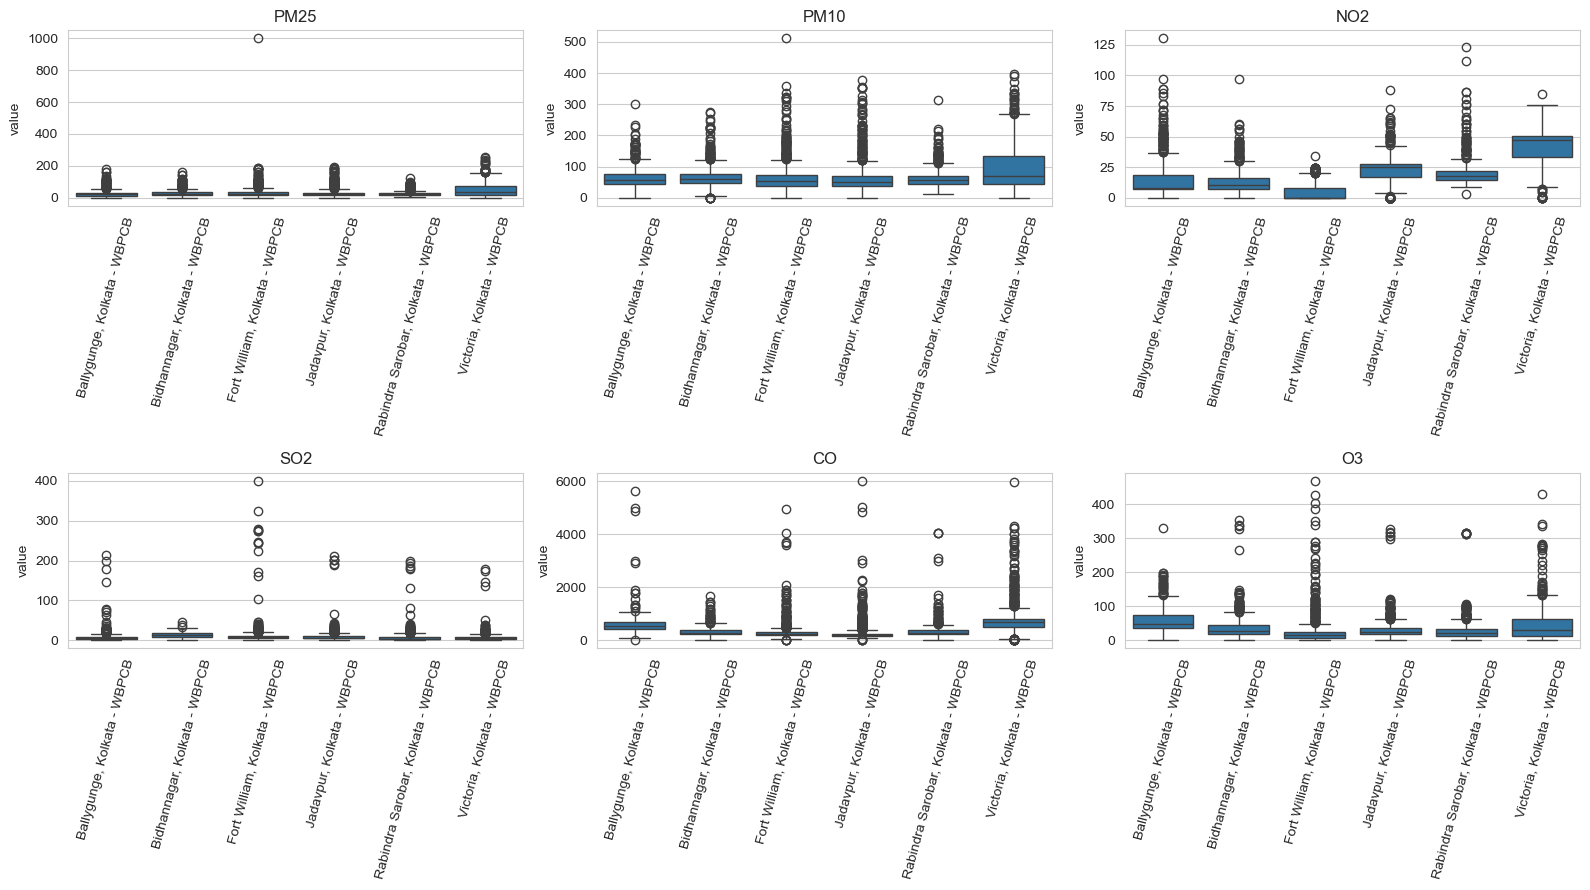

In [15]:
# Plot pollution levels by station

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, p in zip(axes.flat, pollutants):
    sub = df[df['parameter'] == p]
    sns.boxplot(data=sub, x='location_name', y='value', ax=ax)
    ax.set_title(p.upper())
    ax.tick_params(axis='x', rotation=75)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

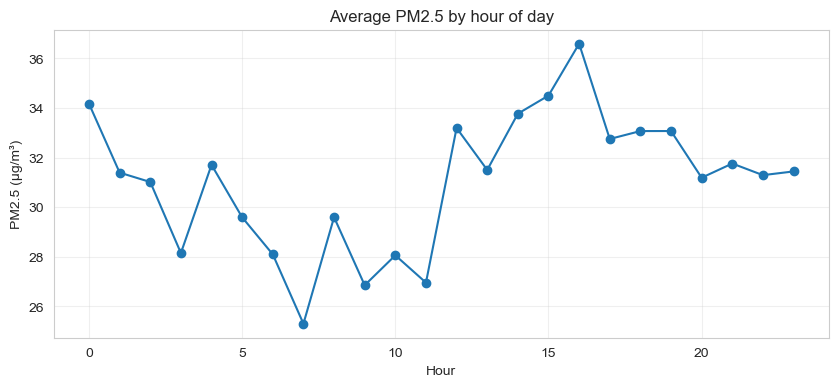

In [28]:
# Filter PM2.5 data to analyze how its average concentration varies throughout the day.
# PM2.5 is examined separately because each pollutant has its own daily pattern.

pm25 = df[df['parameter'] == 'pm25'].copy()
pm25['hour'] = pm25['datetimeLocal'].dt.hour
hourly_avg = pm25.groupby('hour')['value'].mean()

plt.figure(figsize=(10, 4))
hourly_avg.plot(marker='o')
plt.title('Average PM2.5 by hour of day')
plt.xlabel('Hour')
plt.ylabel('PM2.5 (µg/m³)')
plt.grid(True, alpha=0.3)
plt.show()

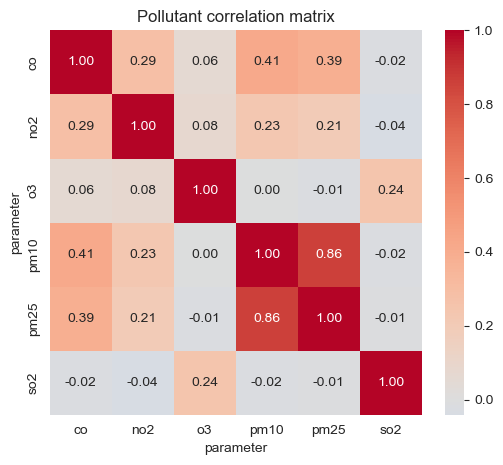

In [29]:
# Plot correlation matrix between pollutants

wide_preview = df.pivot_table(index=['location_name', 'datetimeLocal'], columns='parameter', values='value', aggfunc='mean')
corr = wide_preview.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Pollutant correlation matrix')
plt.show()